<a href="https://colab.research.google.com/github/Sagnik-Chowdhury/Federated-Learning-1/blob/Sagnik/FedProto_NN_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# FedProto: Federated Prototype Learning across Heterogeneous Clients

Implementation based on:

FedProto: Federated Prototype Learning across Heterogeneous Clients
AAAI 2022

Goal:
Implement the algorithm exactly as described in the paper and study the effect
of statistical heterogeneity using Dirichlet partitioning.

# Imports & Configuration

In this section, we import all the libraries required to implement the FedProto algorithm.

The implementation is based on **PyTorch** and uses **MNIST** as the initial dataset because it is lightweight and one of the datasets used in the FedProto paper.

To ensure that experiments are reproducible, we fix the random seeds for Python, NumPy, and PyTorch. This helps obtain consistent results across multiple runs.

This section does not implement any part of the FedProto algorithm directly, but it provides the foundation for all subsequent sections.

In [ ]:
# ============================================================
# Imports
# ============================================================

import random
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset

import torchvision
import torchvision.transforms as transforms
from torchvision import models

# ============================================================
# Configuration
# ============================================================

SEED = 42

NUM_CLIENTS = 5

NUM_ROUNDS = 15

LOCAL_EPOCHS = 1

BATCH_SIZE = 128

LEARNING_RATE = 1e-3

EMBEDDING_DIM = 128

LAMBDA_PROTO = 1.0      # λ in Equation (7)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Using device: {DEVICE}")

Using device: cuda


In [ ]:
# ============================================================
# Reproducibility
# ============================================================

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


set_seed(SEED)

print("Random seed fixed:", SEED)

Random seed fixed: 42


# Dataset

In this implementation, we use the **MNIST** dataset, which consists of grayscale handwritten digit images belonging to **10 classes (0–9)**. Each image has a resolution of **28 × 28** pixels.

The FedProto paper evaluates its method on multiple image classification datasets, including MNIST. We choose MNIST for the initial implementation because it is lightweight, computationally efficient, and easy to debug. Once the implementation is complete, the modular design will allow the dataset to be replaced (e.g., with CIFAR-10) without changing the overall FedProto algorithm.

At this stage, the dataset is downloaded and preprocessed. **No federated partitioning is performed yet**. The entire training dataset remains centralized temporarily and will be divided among clients in the next section using Dirichlet partitioning.

In [ ]:
# ============================================================
# MNIST Dataset
# ============================================================

# Transform:
# Convert images to tensors and normalize pixel values
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

# Download training dataset
train_dataset = torchvision.datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

# Download test dataset
test_dataset = torchvision.datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

print(f"Training samples : {len(train_dataset)}")
print(f"Testing samples  : {len(test_dataset)}")
print(f"Number of classes: {len(train_dataset.classes)}")

100%|██████████| 9.91M/9.91M [00:00<00:00, 19.9MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 480kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.44MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 10.8MB/s]

Training samples : 60000
Testing samples  : 10000
Number of classes: 10


In [ ]:
# ============================================================
# Display Dataset Information
# ============================================================

print("Classes:", train_dataset.classes)

image, label = train_dataset[0]

print(f"Image shape : {image.shape}")
print(f"Label       : {label}")

Classes: ['0 - zero', '1 - one', '2 - two', '3 - three', '4 - four', '5 - five', '6 - six', '7 - seven', '8 - eight', '9 - nine']
Image shape : torch.Size([1, 28, 28])
Label       : 5


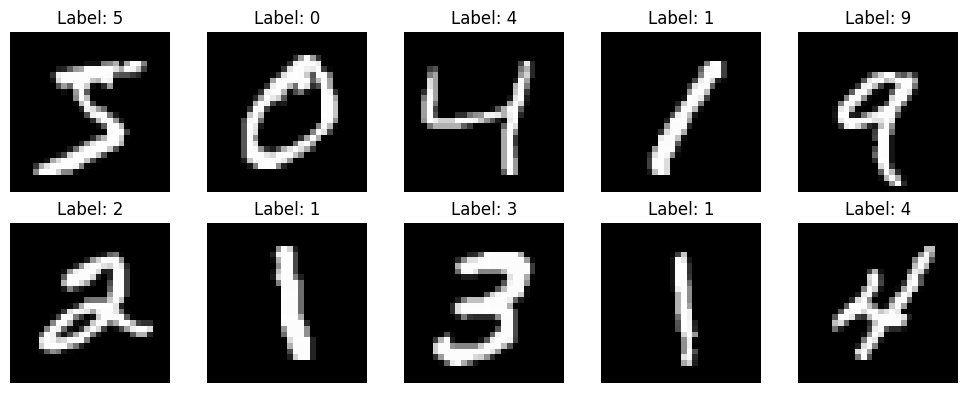

In [ ]:
# ============================================================
# Visualize Sample Images
# ============================================================

fig, axes = plt.subplots(2, 5, figsize=(10, 4))

for i, ax in enumerate(axes.flat):
    image, label = train_dataset[i]

    # Undo normalization for visualization
    image = image * 0.3081 + 0.1307

    ax.imshow(image.squeeze(), cmap="gray")
    ax.set_title(f"Label: {label}")
    ax.axis("off")

plt.tight_layout()
plt.show()

# Federated Data Partition

In a federated learning system, the training dataset is distributed across multiple clients. Each client stores and trains only on its own local data, while the server never accesses the underlying images or labels.

The original **FedProto** paper creates heterogeneous client tasks by assigning different subsets of classes to different clients. In this notebook, however, we use **Dirichlet partitioning** to simulate statistical heterogeneity.

A Dirichlet distribution is commonly used in federated learning research because it provides a simple and controllable way to generate non-IID client datasets.

The concentration parameter **α (alpha)** controls how similar or different the client data distributions are:

- **Large α** → Data is distributed almost uniformly across clients (approximately IID).
- **Small α** → Each client receives data from only a few dominant classes (highly non-IID).

This changes only the **experimental setup**. The FedProto algorithm itself remains exactly the same.

In [ ]:
# ============================================================
# Dirichlet Partitioning
# ============================================================

def dirichlet_partition(dataset, num_clients, alpha, seed=42):
    """
    Partition a dataset among clients using a Dirichlet distribution.

    Parameters
    ----------
    dataset : torchvision Dataset
        Training dataset.

    num_clients : int
        Number of federated clients.

    alpha : float
        Dirichlet concentration parameter.

    seed : int
        Random seed.

    Returns
    -------
    client_indices : dict
        Dictionary mapping each client ID to a list of sample indices.
    """

    np.random.seed(seed)

    labels = np.array(dataset.targets)

    num_classes = len(np.unique(labels))

    client_indices = {i: [] for i in range(num_clients)}

    # Process one class at a time
    for cls in range(num_classes):

        class_indices = np.where(labels == cls)[0]

        np.random.shuffle(class_indices)

        # Sample proportions from Dirichlet distribution
        proportions = np.random.dirichlet(
            alpha=np.repeat(alpha, num_clients)
        )

        # Convert proportions into split points
        split_points = (
            np.cumsum(proportions) * len(class_indices)
        ).astype(int)[:-1]

        class_split = np.split(class_indices, split_points)

        for client_id, indices in enumerate(class_split):
            client_indices[client_id].extend(indices.tolist())

    # Shuffle samples inside each client
    for client_id in client_indices:
        np.random.shuffle(client_indices[client_id])

    return client_indices

In [ ]:
# ============================================================
# Example Partition
# ============================================================

alpha = 0.5

client_indices = dirichlet_partition(
    dataset=train_dataset,
    num_clients=NUM_CLIENTS,
    alpha=alpha,
    seed=SEED
)

for client_id in range(NUM_CLIENTS):
    print(
        f"Client {client_id + 1}: "
        f"{len(client_indices[client_id])} samples"
    )

Client 1: 13910 samples
Client 2: 6144 samples
Client 3: 14834 samples
Client 4: 14432 samples
Client 5: 10680 samples


In [ ]:
# ============================================================
# Verify Partition
# ============================================================

total_samples = sum(len(v) for v in client_indices.values())

print("Total assigned samples:", total_samples)
print("Original dataset size :", len(train_dataset))

assert total_samples == len(train_dataset)

print("✓ Partition verification passed.")

Total assigned samples: 60000
Original dataset size : 60000
✓ Partition verification passed.


# Statistical Heterogeneity

The Dirichlet concentration parameter (**α**) determines how training samples are distributed among federated clients.

As α decreases, the data becomes increasingly **non-IID**, meaning each client contains a more biased subset of the overall dataset. This statistical heterogeneity is one of the primary challenges in federated learning because clients learn from different local distributions.

Before training the FedProto algorithm, it is useful to visualize the class distribution of each client. This helps verify that the partitioning behaves as expected and provides intuition about the difficulty of the learning task.

In the experiments later in this notebook, we will evaluate FedProto under multiple values of α:

- α = 10.0 (Almost IID)
- α = 1.0
- α = 0.5
- α = 0.25
- α = 0.10
- α = 0.05 (Highly Non-IID)

In [ ]:
# ============================================================
# Compute Class Distribution for Each Client
# ============================================================

def compute_client_distribution(dataset, client_indices, num_classes=10):
    """
    Compute the number of samples of each class
    owned by every client.
    """

    labels = np.array(dataset.targets)

    distribution = np.zeros((len(client_indices), num_classes), dtype=int)

    for client_id, indices in client_indices.items():

        client_labels = labels[indices]

        for cls in range(num_classes):
            distribution[client_id, cls] = np.sum(client_labels == cls)

    return distribution

In [ ]:
# ============================================================
# Plot Client Class Distribution
# ============================================================

def plot_class_distribution(distribution, alpha):
    """
    Plot stacked bar chart showing the class
    distribution of each federated client.
    """

    num_clients, num_classes = distribution.shape

    plt.figure(figsize=(12, 6))

    bottom = np.zeros(num_clients)

    for cls in range(num_classes):
        plt.bar(
            np.arange(num_clients),
            distribution[:, cls],
            bottom=bottom,
            label=f"Class {cls}"
        )
        bottom += distribution[:, cls]

    plt.xlabel("Client")
    plt.ylabel("Number of Samples")
    plt.title(f"Client Class Distribution (Dirichlet α = {alpha})")

    plt.xticks(
        np.arange(num_clients),
        [f"C{i+1}" for i in range(num_clients)]
    )

    plt.legend(
        bbox_to_anchor=(1.02, 1),
        loc="upper left"
    )

    plt.tight_layout()
    plt.show()

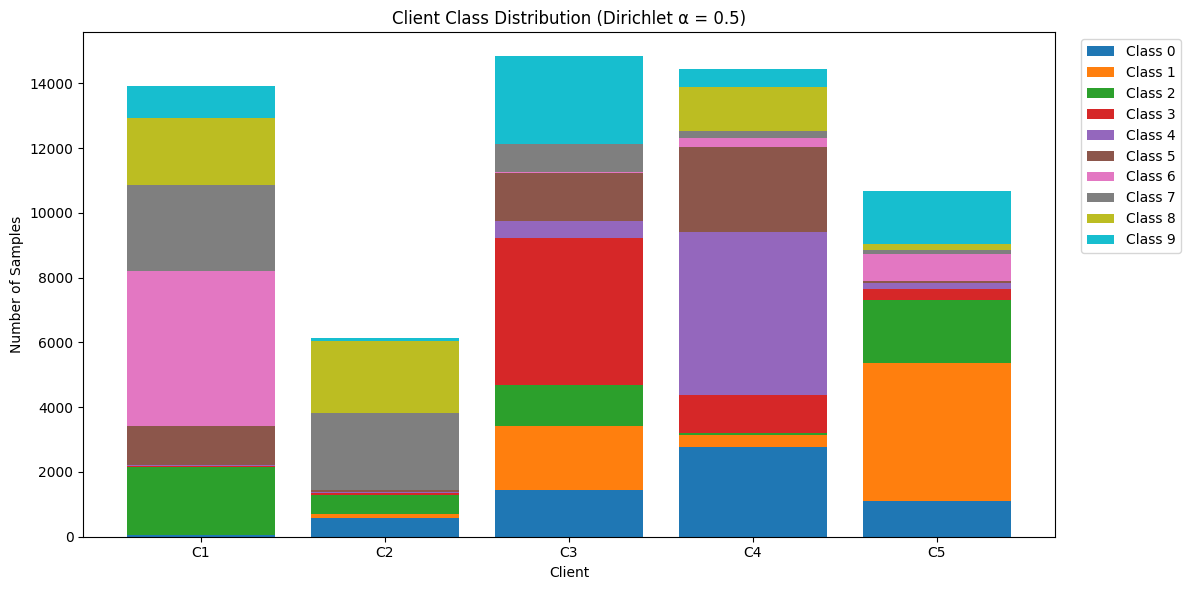

In [ ]:
# ============================================================
# Example Visualization
# ============================================================

distribution = compute_client_distribution(
    train_dataset,
    client_indices
)

plot_class_distribution(
    distribution,
    alpha
)

Dirichlet α = 10.0


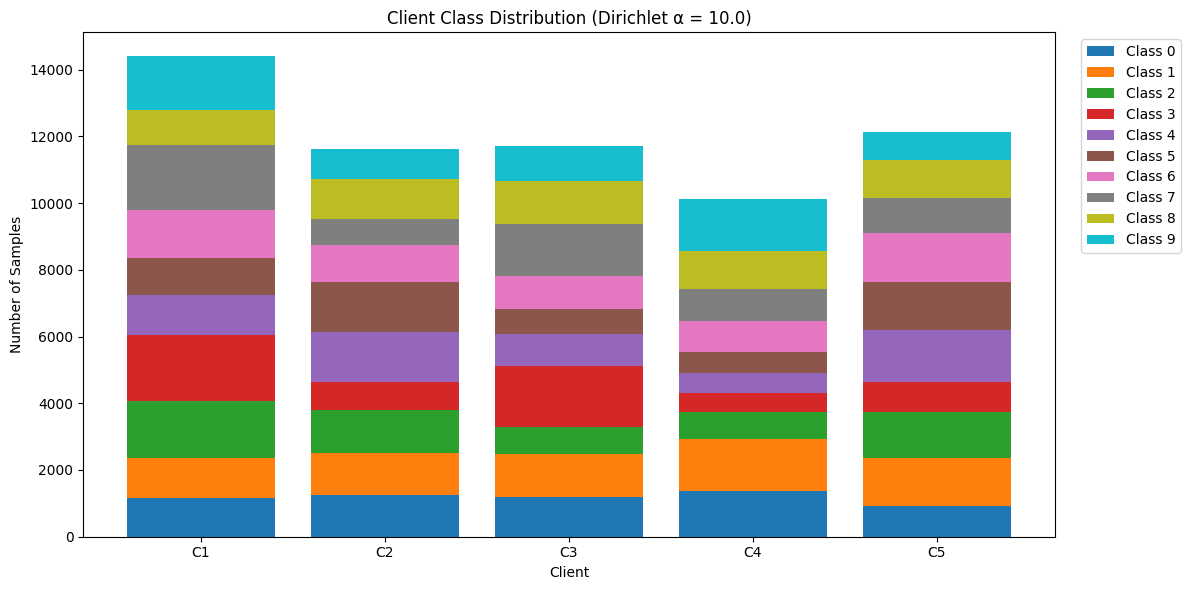

Dirichlet α = 1.0


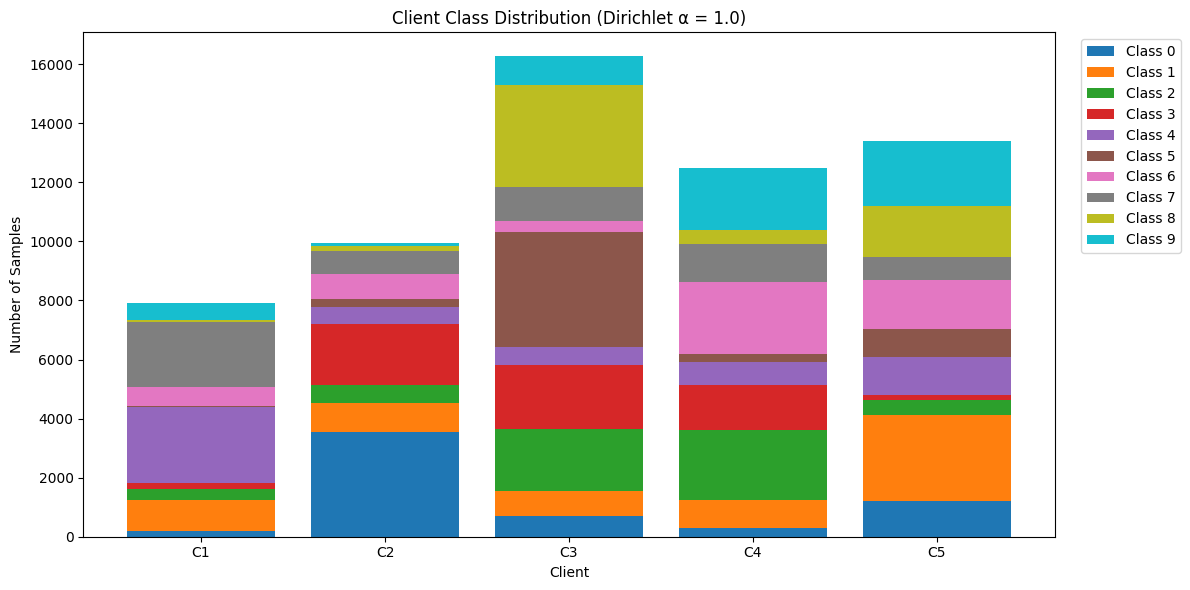

Dirichlet α = 0.5


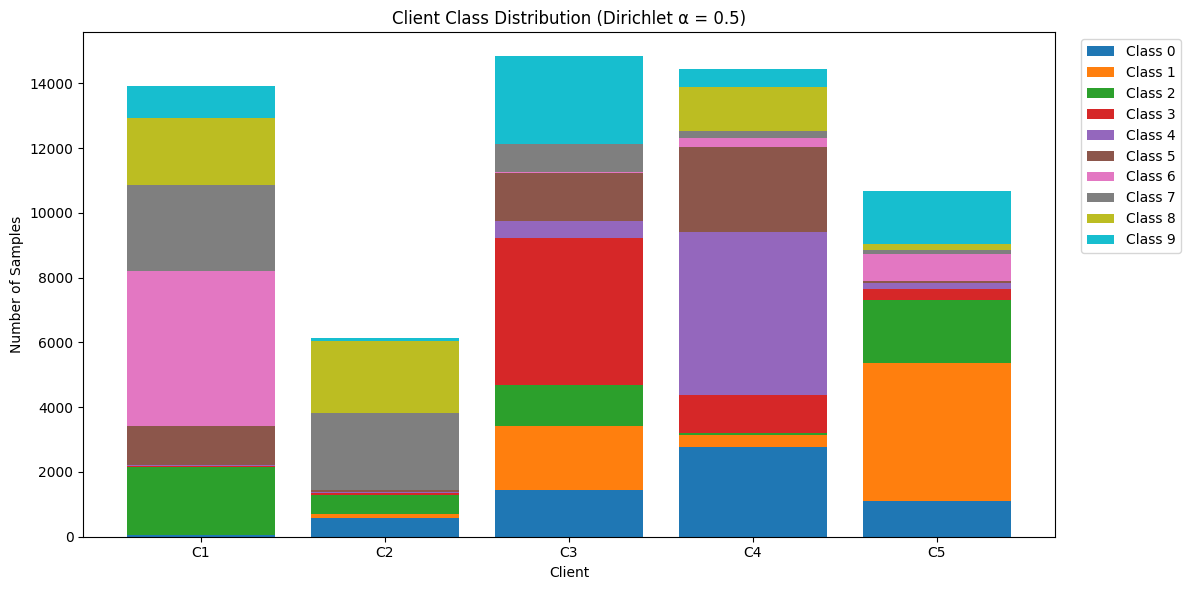

Dirichlet α = 0.25


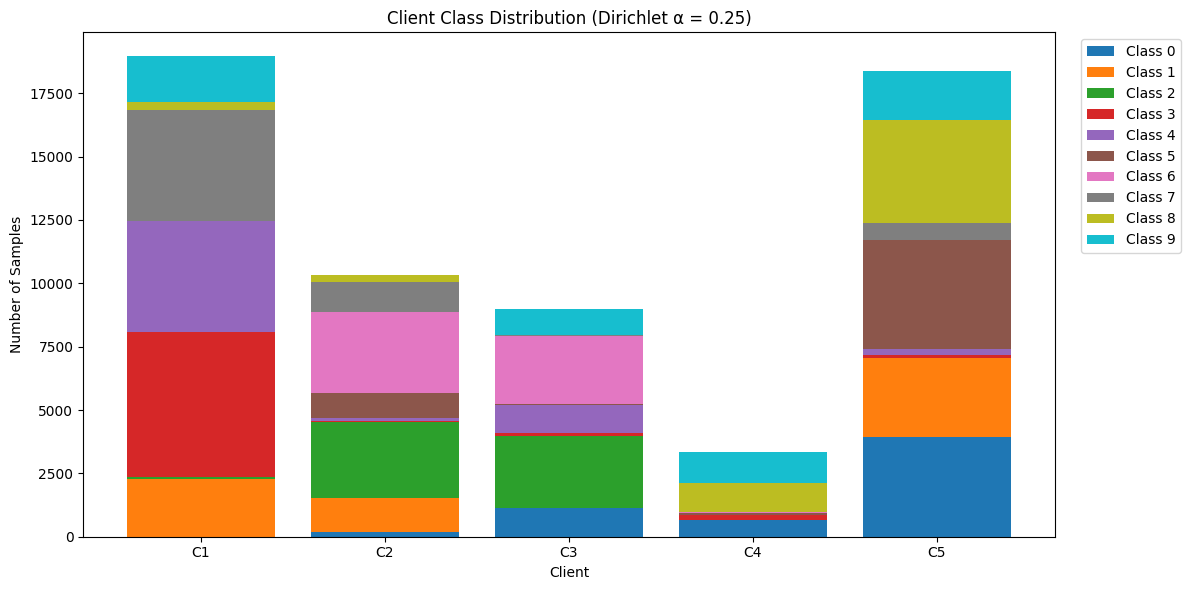

Dirichlet α = 0.1


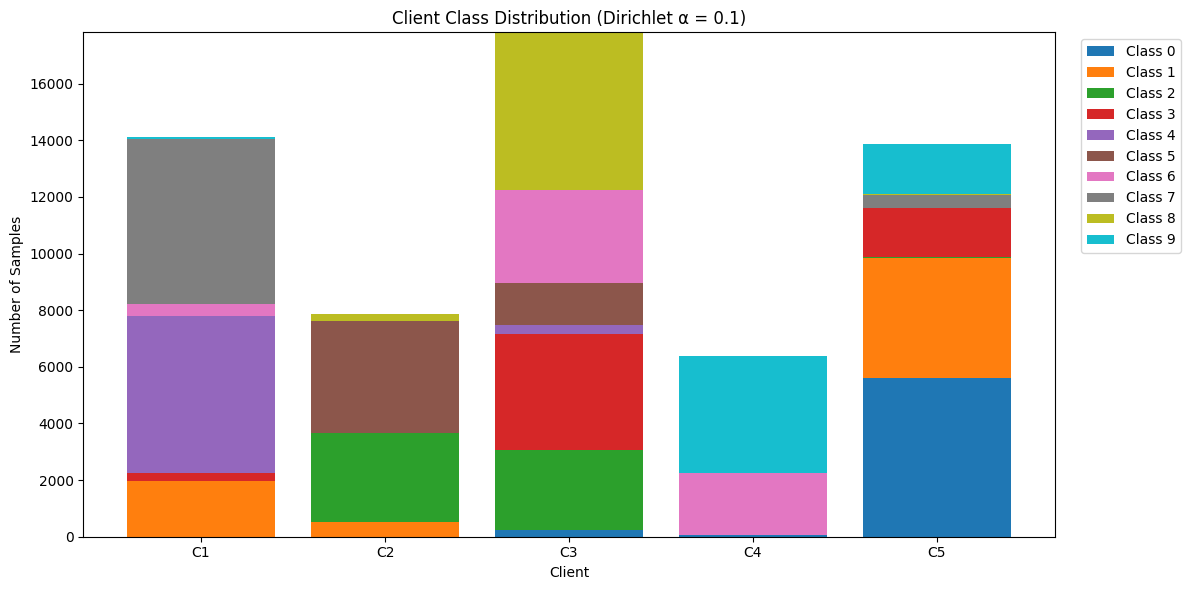

Dirichlet α = 0.05


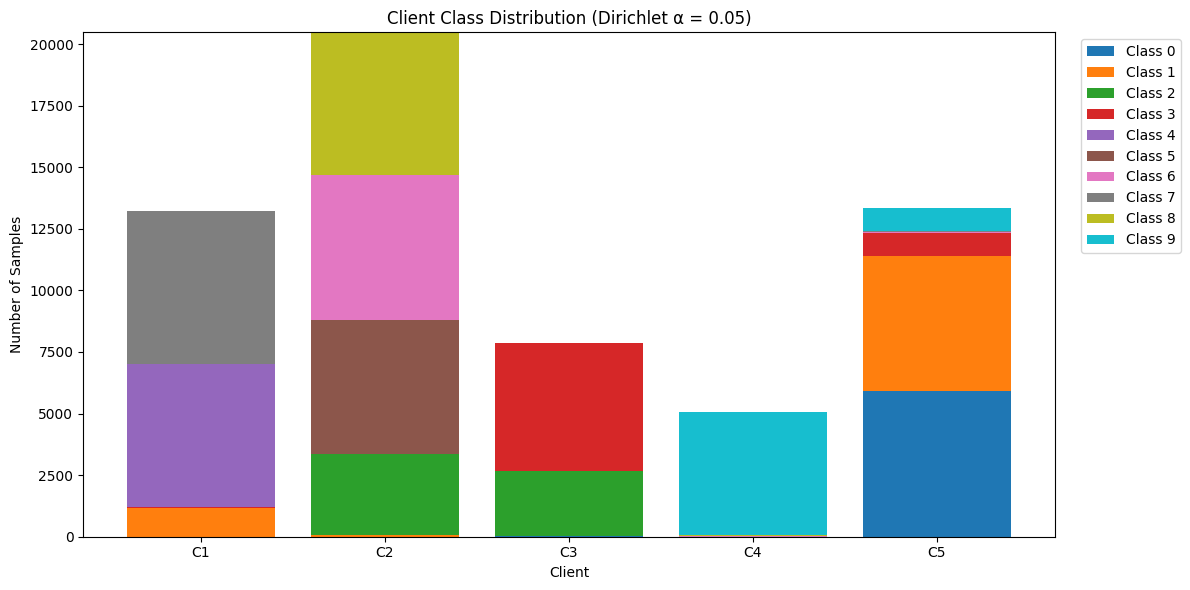

In [ ]:
# ============================================================
# Compare Different Dirichlet Alphas
# ============================================================

alphas = [10.0, 1.0, 0.5, 0.25, 0.10, 0.05]

for alpha in alphas:

    print("=" * 60)
    print(f"Dirichlet α = {alpha}")

    client_indices = dirichlet_partition(
        train_dataset,
        NUM_CLIENTS,
        alpha,
        seed=SEED
    )

    distribution = compute_client_distribution(
        train_dataset,
        client_indices
    )

    plot_class_distribution(
        distribution,
        alpha
    )

# Client DataLoaders

After partitioning the dataset, each client receives only its assigned subset of training samples.

In a real federated learning system, these subsets would reside on different physical devices (e.g., mobile phones, hospitals, or edge devices). Each client trains its model locally using only its own data, and the server never accesses the underlying images or labels.

To simulate this setting, we create an independent `DataLoader` for every client. Each client will later receive only its own `DataLoader` during local training.

At this stage, the server knows only that clients exist—it does not know the contents of their datasets.

In [ ]:
# ============================================================
# Create Client Datasets
# ============================================================

def create_client_datasets(dataset, client_indices):
    """
    Create a local dataset for each client.

    Parameters
    ----------
    dataset : torchvision Dataset
    client_indices : dict

    Returns
    -------
    client_datasets : dict
        client_id -> Subset(dataset)
    """

    client_datasets = {}

    for client_id, indices in client_indices.items():
        client_datasets[client_id] = Subset(dataset, indices)

    return client_datasets

In [ ]:
# ============================================================
# Create Client DataLoaders
# ============================================================

def create_client_dataloaders(
    client_datasets,
    batch_size=BATCH_SIZE,
    shuffle=True
):
    """
    Create one DataLoader for each client.
    """

    client_loaders = {}

    for client_id, dataset in client_datasets.items():

        client_loaders[client_id] = DataLoader(
            dataset,
            batch_size=batch_size,
            shuffle=shuffle,
            drop_last=False
        )

    return client_loaders

In [ ]:
# ============================================================
# Build Local Client DataLoaders
# ============================================================

client_datasets = create_client_datasets(
    train_dataset,
    client_indices
)

client_loaders = create_client_dataloaders(
    client_datasets,
    batch_size=BATCH_SIZE
)

print(f"Created {len(client_loaders)} client DataLoaders.")

Created 5 client DataLoaders.


In [ ]:
# ============================================================
# Verify Client Dataset Sizes
# ============================================================

for client_id in range(NUM_CLIENTS):

    dataset_size = len(client_datasets[client_id])

    num_batches = len(client_loaders[client_id])

    print(
        f"Client {client_id + 1}: "
        f"{dataset_size} samples | "
        f"{num_batches} batches"
    )

Client 1: 13240 samples | 104 batches
Client 2: 20477 samples | 160 batches
Client 3: 7864 samples | 62 batches
Client 4: 5076 samples | 40 batches
Client 5: 13343 samples | 105 batches


In [ ]:
# ============================================================
# Inspect One Local Batch
# ============================================================

images, labels = next(iter(client_loaders[0]))

print("Images shape :", images.shape)
print("Labels shape :", labels.shape)

print("Labels in first batch:")
print(labels)

Images shape : torch.Size([128, 1, 28, 28])
Labels shape : torch.Size([128])
Labels in first batch:
tensor([4, 7, 4, 4, 7, 4, 7, 4, 7, 4, 1, 4, 7, 4, 4, 7, 4, 7, 7, 4, 1, 7, 7, 7,
        7, 7, 4, 7, 1, 4, 7, 4, 7, 7, 1, 7, 4, 7, 4, 7, 4, 7, 4, 7, 4, 4, 4, 7,
        4, 4, 4, 7, 7, 7, 4, 7, 7, 4, 4, 7, 7, 7, 4, 4, 7, 7, 1, 7, 4, 7, 4, 7,
        7, 7, 7, 7, 7, 4, 7, 4, 7, 7, 4, 4, 7, 4, 7, 4, 7, 4, 7, 7, 1, 4, 4, 4,
        4, 1, 4, 4, 4, 7, 7, 4, 1, 7, 1, 4, 7, 4, 4, 7, 1, 7, 7, 7, 4, 4, 7, 7,
        4, 4, 4, 1, 7, 7, 1, 7])


# Heterogeneous Client Models

One of the main advantages of FedProto is that participating clients are **not required to use identical neural network architectures**.

In traditional federated learning methods such as FedAvg, model parameters are averaged across clients. This requires every client to have exactly the same network architecture.

FedProto removes this restriction by exchanging **class prototypes** instead of model parameters. As long as every client produces feature embeddings of the same dimension, prototypes can be aggregated even when the underlying models are different.

Each client model follows the same high-level structure:

Input Image

↓

Feature Extractor

↓

Embedding Layer (128-dimensional)

↓

Classifier

The **embedding layer** represents the latent feature space used to compute class prototypes (Equation (3) of the paper), while the classifier predicts the class labels used for the classification loss in Equation (7).

In this implementation, every model outputs:

- **Embedding**: a fixed-length feature vector used for prototype computation.
- **Logits**: class scores used for classification.

Although the internal architectures differ, the embedding dimension is fixed at **128** for all clients.

In [ ]:
# ============================================================
# Base Model Interface
# ============================================================

class FedProtoModel(nn.Module):
    """
    Base class for all FedProto models.

    Every model returns:
        embedding : Feature representation
        logits    : Classification output
    """

    def forward(self, x):
        raise NotImplementedError

In [ ]:
# ============================================================
# Small CNN
# ============================================================

class SmallCNN(FedProtoModel):

    def __init__(self,
                 embedding_dim=EMBEDDING_DIM,
                 num_classes=10):

        super().__init__()

        self.features = nn.Sequential(

            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(),

            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),

            nn.MaxPool2d(2)
        )

        self.embedding = nn.Sequential(

            nn.Flatten(),

            nn.Linear(64 * 7 * 7, embedding_dim),

            nn.ReLU()
        )

        self.classifier = nn.Linear(
            embedding_dim,
            num_classes
        )

    def forward(self, x):

        x = self.features(x)

        embedding = self.embedding(x)

        logits = self.classifier(embedding)

        return embedding, logits

In [ ]:
# ============================================================
# Large CNN
# ============================================================

class LargeCNN(FedProtoModel):

    def __init__(self,
                 embedding_dim=EMBEDDING_DIM,
                 num_classes=10):

        super().__init__()

        self.features = nn.Sequential(

            nn.Conv2d(1, 32, 3, padding=1),
            nn.ReLU(),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),

            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),

            nn.MaxPool2d(2)
        )

        self.embedding = nn.Sequential(

            nn.Flatten(),

            nn.Linear(128 * 7 * 7, embedding_dim),

            nn.ReLU()
        )

        self.classifier = nn.Linear(
            embedding_dim,
            num_classes
        )

    def forward(self, x):

        x = self.features(x)

        embedding = self.embedding(x)

        logits = self.classifier(embedding)

        return embedding, logits

In [ ]:
# ============================================================
# Multi-Layer Perceptron
# ============================================================

class MLP(FedProtoModel):

    def __init__(self,
                 embedding_dim=EMBEDDING_DIM,
                 num_classes=10):

        super().__init__()

        self.feature_extractor = nn.Sequential(

            nn.Flatten(),

            nn.Linear(28 * 28, 512),

            nn.ReLU(),

            nn.Linear(512, embedding_dim),

            nn.ReLU()
        )

        self.classifier = nn.Linear(
            embedding_dim,
            num_classes
        )

    def forward(self, x):

        embedding = self.feature_extractor(x)

        logits = self.classifier(embedding)

        return embedding, logits

In [ ]:
# ============================================================
# Verify Model Outputs
# ============================================================

dummy = torch.randn(4, 1, 28, 28)

models_to_test = [
    SmallCNN(),
    LargeCNN(),
    MLP()
]

for model in models_to_test:

    embedding, logits = model(dummy)

    print(model.__class__.__name__)

    print("Embedding:", embedding.shape)

    print("Logits    :", logits.shape)

    print("-" * 40)

SmallCNN
Embedding: torch.Size([4, 128])
Logits    : torch.Size([4, 10])
----------------------------------------
LargeCNN
Embedding: torch.Size([4, 128])
Logits    : torch.Size([4, 10])
----------------------------------------
MLP
Embedding: torch.Size([4, 128])
Logits    : torch.Size([4, 10])
----------------------------------------


## Additional Heterogeneous Models

To further demonstrate heterogeneous federated learning, we include two widely used convolutional neural network architectures:

- ResNet18
- MobileNetV2

These models are originally designed for RGB images of size 224 × 224. Since MNIST contains grayscale images of size 28 × 28, we make two adaptations:

1. Replace the first convolutional layer to accept one input channel.
2. Replace the original classifier with:
   - a 128-dimensional embedding layer,
   - followed by a classification layer.

These changes preserve the overall architecture while ensuring that every client produces embeddings of the same dimension, allowing prototype aggregation in FedProto.

In [ ]:
# ============================================================
# ResNet18
# ============================================================

class ResNet18Model(FedProtoModel):

    def __init__(self,
                 embedding_dim=EMBEDDING_DIM,
                 num_classes=10):

        super().__init__()

        self.backbone = models.resnet18(weights=None)

        # Accept grayscale images
        self.backbone.conv1 = nn.Conv2d(
            in_channels=1,
            out_channels=64,
            kernel_size=7,
            stride=2,
            padding=3,
            bias=False
        )

        feature_dim = self.backbone.fc.in_features

        # Remove original classifier
        self.backbone.fc = nn.Identity()

        # Embedding layer
        self.embedding = nn.Sequential(
            nn.Linear(feature_dim, embedding_dim),
            nn.ReLU()
        )

        # Final classifier
        self.classifier = nn.Linear(
            embedding_dim,
            num_classes
        )

    def forward(self, x):

        features = self.backbone(x)

        embedding = self.embedding(features)

        logits = self.classifier(embedding)

        return embedding, logits

In [ ]:
# ============================================================
# MobileNetV2
# ============================================================

class MobileNetV2Model(FedProtoModel):

    def __init__(self,
                 embedding_dim=EMBEDDING_DIM,
                 num_classes=10):

        super().__init__()

        self.backbone = models.mobilenet_v2(weights=None)

        # Accept grayscale images
        self.backbone.features[0][0] = nn.Conv2d(
            1,
            32,
            kernel_size=3,
            stride=2,
            padding=1,
            bias=False
        )

        feature_dim = self.backbone.last_channel

        # Remove original classifier
        self.backbone.classifier = nn.Identity()

        # Embedding layer
        self.embedding = nn.Sequential(
            nn.Linear(feature_dim, embedding_dim),
            nn.ReLU()
        )

        self.classifier = nn.Linear(
            embedding_dim,
            num_classes
        )

    def forward(self, x):

        features = self.backbone(x)

        embedding = self.embedding(features)

        logits = self.classifier(embedding)

        return embedding, logits

In [ ]:
# ============================================================
# Verify All Model Architectures
# ============================================================

dummy = torch.randn(4, 1, 28, 28)

models_to_test = [
    SmallCNN(),
    LargeCNN(),
    MLP(),
    ResNet18Model(),
    MobileNetV2Model()
]

for model in models_to_test:

    embedding, logits = model(dummy)

    print(f"{model.__class__.__name__}")

    print(f"Embedding Shape : {embedding.shape}")

    print(f"Logits Shape    : {logits.shape}")

    print("-" * 50)

SmallCNN
Embedding Shape : torch.Size([4, 128])
Logits Shape    : torch.Size([4, 10])
--------------------------------------------------
LargeCNN
Embedding Shape : torch.Size([4, 128])
Logits Shape    : torch.Size([4, 10])
--------------------------------------------------
MLP
Embedding Shape : torch.Size([4, 128])
Logits Shape    : torch.Size([4, 10])
--------------------------------------------------
ResNet18Model
Embedding Shape : torch.Size([4, 128])
Logits Shape    : torch.Size([4, 10])
--------------------------------------------------
MobileNetV2Model
Embedding Shape : torch.Size([4, 128])
Logits Shape    : torch.Size([4, 10])
--------------------------------------------------


In [ ]:
# ============================================================
# Model Factory
# ============================================================

def create_model(model_name):
    """
    Create a client model based on its name.
    """

    if model_name == "SmallCNN":
        return SmallCNN()

    elif model_name == "LargeCNN":
        return LargeCNN()

    elif model_name == "MLP":
        return MLP()

    elif model_name == "ResNet18":
        return ResNet18Model()

    elif model_name == "MobileNetV2":
        return MobileNetV2Model()

    else:
        raise ValueError(f"Unknown model: {model_name}")

In [ ]:
# ============================================================
# Assign Different Models to Clients
# ============================================================

client_model_names = [
    "SmallCNN",
    "LargeCNN",
    "MLP",
    "ResNet18",
    "MobileNetV2"
]

client_models = {
    client_id: create_model(model_name).to(DEVICE)
    for client_id, model_name in enumerate(client_model_names)
}

print("Client Model Assignment")

for client_id, model_name in enumerate(client_model_names):
    print(f"Client {client_id + 1} → {model_name}")

Client Model Assignment
Client 1 → SmallCNN
Client 2 → LargeCNN
Client 3 → MLP
Client 4 → ResNet18
Client 5 → MobileNetV2


# Client

In FedProto, each federated client performs local training using only its own private dataset. Clients never share their model parameters, gradients, embeddings, or raw data with the server.

Instead, each client is responsible for:

- Maintaining its own neural network.
- Training on its local dataset.
- Computing class prototypes from its learned embeddings (Equation (3)).
- Sending only the computed prototypes to the server.

In this section, we define the basic client structure. The communication protocol and local training procedure will be implemented in later sections following Algorithm 1 of the paper.

In [ ]:
class Client:

    def __init__(
        self,
        client_id,
        model,
        train_loader,
        device=DEVICE,
        lr=LEARNING_RATE
    ):

        self.client_id = client_id
        self.device = device

        self.model = model.to(device)

        self.train_loader = train_loader

        self.criterion = nn.CrossEntropyLoss()

        self.optimizer = torch.optim.Adam(
            self.model.parameters(),
            lr=lr
        )

        self.prototypes = {}

        self.num_samples = len(train_loader.dataset)

    def train_mode(self):
        self.model.train()

    def eval_mode(self):
        self.model.eval()

    def get_model(self):
        return self.model

    def get_prototypes(self):
        return self.prototypes

    def get_num_samples(self):
        return self.num_samples

    # ============================================================
    # Equation (3)
    # ============================================================
    def compute_prototypes(self):

        self.model.eval()

        class_embeddings = defaultdict(list)

        with torch.no_grad():

            for images, labels in self.train_loader:

                images = images.to(self.device)
                labels = labels.to(self.device)

                embeddings, _ = self.model(images)

                for embedding, label in zip(embeddings, labels):

                    class_embeddings[label.item()].append(
                        embedding.detach().cpu()
                    )

        prototypes = {}

        for cls, embeddings in class_embeddings.items():

            prototypes[cls] = torch.stack(
                embeddings
            ).mean(dim=0)

        self.prototypes = prototypes

        return prototypes


  # ============================================================
# Local Class Counts
# ============================================================

    def get_class_counts(self):
        """
        Compute the number of samples belonging to each class.

        Returns
        -------
        dict
            class_id -> number of local samples
        """

        class_counts = defaultdict(int)

        for _, labels in self.train_loader:

            for label in labels:
                class_counts[label.item()] += 1

        return dict(class_counts)

# ============================================================
# Equation (7)
# Prototype Regularization Loss
    # ============================================================

    def prototype_regularization_loss(self, embeddings, labels, global_prototypes):
        """
        Compute the prototype regularization term in Equation (7).

        Parameters
        ----------
        embeddings : Tensor
            Shape: (batch_size, embedding_dim)

        labels : Tensor
            Shape: (batch_size,)

        global_prototypes : dict
            class_id -> global prototype

        Returns
        -------
        Tensor
            Prototype regularization loss.
        """

        loss = torch.tensor(0.0, device=self.device)

        count = 0

        for embedding, label in zip(embeddings, labels):

            cls = label.item()

            # Skip if no global prototype exists
            if cls not in global_prototypes:
                continue

            global_proto = global_prototypes[cls].to(self.device)

            loss += F.mse_loss(
                embedding,
                global_proto,
                reduction="mean"
            )

            count += 1

        if count > 0:
            loss /= count

        return loss

  # ============================================================
# Algorithm 1
# Local Training
# ============================================================

    def local_train(self, global_prototypes, local_epochs=LOCAL_EPOCHS):
        """
        Perform local training according to Algorithm 1.

        Parameters
        ----------
        global_prototypes : dict
            Current global prototypes broadcast by the server.

        local_epochs : int
            Number of local training epochs.

        Returns
        -------
        float
            Average training loss.
        """

        self.model.train()

        total_loss = 0.0
        total_batches = 0

        for epoch in range(local_epochs):

            for images, labels in self.train_loader:

                images = images.to(self.device)
                labels = labels.to(self.device)

                # ----------------------------
                # Forward Pass
                # ----------------------------
                embeddings, logits = self.model(images)

                # Classification Loss
                classification_loss = self.criterion(
                    logits,
                    labels
                )

                # Prototype Regularization Loss
                prototype_loss = self.prototype_regularization_loss(
                    embeddings,
                    labels,
                    global_prototypes
                )

                # Equation (7)
                loss = (
                    classification_loss
                    + LAMBDA_PROTO * prototype_loss
                )

                # ----------------------------
                # Backpropagation
                # ----------------------------
                self.optimizer.zero_grad()

                loss.backward()

                self.optimizer.step()

                total_loss += loss.item()
                total_batches += 1

        # Recompute local prototypes
        self.compute_prototypes()

        return total_loss / total_batches

In [ ]:
clients = []

for client_id in range(NUM_CLIENTS):

    client = Client(
        client_id=client_id,
        model=client_models[client_id],
        train_loader=client_loaders[client_id]
    )

    clients.append(client)

In [ ]:
client = clients[0]

print("Client ID      :", client.client_id)

print("Samples        :", client.get_num_samples())

print("Model          :", client.model.__class__.__name__)

#print("Prototype Dict :", client.get_prototypes())

Client ID      : 0
Samples        : 13240
Model          : SmallCNN


# Local Prototype Computation (Equation 3)

The central idea of FedProto is to represent each class by a **prototype**, which is the average feature embedding of all local samples belonging to that class.

For a client $ i$, the prototype of class $ j$ is computed as

$
C_i^{(j)}
=
\frac{1}{|D_{i,j}|}
\sum_{(x,y)\in D_{i,j}}
f_i(x)
$

where

- $D_{i,j}$ is the set of local samples belonging to class \(j\),
- $f_i(x)$ is the embedding produced by the client's feature extractor.

Only these prototypes are transmitted to the server. No images, labels, embeddings of individual samples, gradients, or model parameters leave the client.

This corresponds directly to **Equation (3)** of the FedProto paper.

In [ ]:
# ============================================================
# Compute Local Prototypes
# ============================================================

client = clients[0]

prototypes = client.compute_prototypes()

print(f"Client {client.client_id}")

print(f"Number of prototypes: {len(prototypes)}")

Client 0
Number of prototypes: 5


In [ ]:
# ============================================================
# Inspect Prototype Dimensions
# ============================================================

for cls, proto in prototypes.items():

    print(

        f"Class {cls}:",

        proto.shape
    )

Class 7: torch.Size([128])
Class 1: torch.Size([128])
Class 4: torch.Size([128])
Class 3: torch.Size([128])
Class 9: torch.Size([128])


In [ ]:
# ============================================================
# Available Classes on Each Client
# ============================================================

for client in clients:

    prototypes = client.compute_prototypes()

    classes = sorted(prototypes.keys())

    print(

        f"Client {client.client_id}:",

        classes
    )

Client 0: [1, 3, 4, 7, 9]
Client 1: [1, 2, 5, 6, 8]
Client 2: [0, 2, 3, 4, 5, 8]
Client 3: [6, 8, 9]
Client 4: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


## Retrieving Local Prototypes

After computing the local class prototypes using Equation (3), the client stores them internally.

During each communication round (Algorithm 1), the server requests these stored prototypes from every client for aggregation.

The `get_prototypes()` method simply returns the prototypes that have already been computed. It does **not** recompute them.

Separating prototype computation from prototype retrieval improves the modularity of the implementation. The client computes prototypes only once after local training, while the server can retrieve them whenever needed without repeating the computation.

In [ ]:
# ============================================================
# Verify Prototype Retrieval
# ============================================================

client = clients[0]

# Compute prototypes once
client.compute_prototypes()

# Retrieve stored prototypes
stored_prototypes = client.get_prototypes()

print(f"Number of stored prototypes: {len(stored_prototypes)}")

print("Available classes:")

print(sorted(stored_prototypes.keys()))

Number of stored prototypes: 5
Available classes:
[1, 3, 4, 7, 9]


In [ ]:

# ============================================================
# Inspect One Prototype
# ============================================================

first_class = list(stored_prototypes.keys())[0]

print("Class:", first_class)

print("Prototype Shape:")

print(stored_prototypes[first_class].shape)

Class: 7
Prototype Shape:
torch.Size([128])


# Server

Unlike traditional federated learning methods such as FedAvg, the server in FedProto does **not** maintain or aggregate a global neural network.

Instead, the server stores only the **global class prototypes**.

During each communication round, the server:

1. Receives local prototypes from participating clients.
2. Aggregates the prototypes according to Equation (6) of the paper.
3. Broadcasts the updated global prototypes back to the clients.

At no point does the server access client images, labels, feature embeddings, or model parameters.

In [ ]:
# ============================================================
# FedProto Server
# ============================================================

class Server:
    """
    FedProto Server

    Responsibilities
    ----------------
    - Store global prototypes
    - Aggregate local prototypes
    - Broadcast global prototypes
    """

    def __init__(self):

        # Global prototypes
        # {class_id : prototype}
        self.global_prototypes = {}

# ============================================================
# Broadcast Global Prototypes
# ============================================================

    def broadcast_prototypes(self):
        """
        Return the current global prototypes.

        Returns
        -------
        dict
            class_id -> prototype
        """

        return self.global_prototypes

# ============================================================
# Update Global Prototypes
# ============================================================

    def set_global_prototypes(self, prototypes):
        """
        Replace the current global prototypes.

        Parameters
        ----------
        prototypes : dict
            Aggregated global prototypes.
        """

        self.global_prototypes = prototypes

# ============================================================
# Number of Global Prototypes
# ============================================================

    def num_global_prototypes(self):
        """
        Returns the number of stored global prototypes.
        """

        return len(self.global_prototypes)


  # ============================================================
# Equation (6)
# Aggregate Local Prototypes
# ============================================================

    def aggregate_prototypes(self, clients):
        """
        Aggregate local prototypes according to Equation (6).

        Parameters
        ----------
        clients : list
            List of Client objects.
        """

        aggregated = {}

        # All classes present among participating clients
        all_classes = set()

        for client in clients:
            all_classes.update(client.get_prototypes().keys())

        # Aggregate each class independently
        for cls in sorted(all_classes):

            weighted_sum = None
            total_samples = 0

            for client in clients:

                prototypes = client.get_prototypes()

                if cls not in prototypes:
                    continue

                class_count = client.get_class_counts().get(cls, 0)

                if class_count == 0:
                    continue

                prototype = prototypes[cls]

                if weighted_sum is None:
                    weighted_sum = class_count * prototype
                else:
                    weighted_sum += class_count * prototype

                total_samples += class_count

            if total_samples > 0:
                aggregated[cls] = weighted_sum / total_samples

        self.global_prototypes = aggregated

        return aggregated


In [ ]:
# ============================================================
# Create Server
# ============================================================

server = Server()

print("Server initialized.")

print("Global prototypes:", server.global_prototypes)

Server initialized.
Global prototypes: {}


In [ ]:
# ============================================================
# Test Prototype Storage
# ============================================================

client = clients[0]

client.compute_prototypes()

local_prototypes = client.get_prototypes()

server.set_global_prototypes(local_prototypes)

received = server.broadcast_prototypes()

print(f"Number of global prototypes: {len(received)}")

print("Classes:")

print(sorted(received.keys()))

Number of global prototypes: 5
Classes:
[1, 3, 4, 7, 9]


In [ ]:
# ============================================================
# Test Prototype Storage
# ============================================================

client = clients[0]

client.compute_prototypes()

local_prototypes = client.get_prototypes()

server.set_global_prototypes(local_prototypes)

received = server.broadcast_prototypes()

print(f"Number of global prototypes: {len(received)}")

print("Classes:")

print(sorted(received.keys()))

Number of global prototypes: 5
Classes:
[1, 3, 4, 7, 9]


# Prototype Aggregation (Equation 6)

After completing local training, each client computes a prototype for every class present in its local dataset and sends these prototypes to the server.

The server aggregates the received prototypes class by class to construct the global prototypes.

For a given class, only clients that possess samples of that class contribute to the aggregation. Clients that do not contain a particular class simply do not participate in the aggregation for that class.

The FedProto paper aggregates local prototypes using a **weighted average**, where the weight of each client's prototype is proportional to the number of local samples belonging to that class.

This corresponds to **Equation (6)** of the FedProto paper.

The resulting global prototypes are then broadcast back to all clients in the next communication round.

In [ ]:
# ============================================================
# Compute Local Prototypes
# ============================================================

for client in clients:
    client.compute_prototypes()

In [ ]:
# ============================================================
# Server Aggregation
# ============================================================

global_prototypes = server.aggregate_prototypes(clients)

print(f"Number of global prototypes: {len(global_prototypes)}")

print("Available classes:")

print(sorted(global_prototypes.keys()))

Number of global prototypes: 10
Available classes:
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


In [ ]:
# ============================================================
# Inspect Global Prototype Dimensions
# ============================================================

for cls, prototype in global_prototypes.items():

    print(

        f"Class {cls}:",

        prototype.shape
    )

Class 0: torch.Size([128])
Class 1: torch.Size([128])
Class 2: torch.Size([128])
Class 3: torch.Size([128])
Class 4: torch.Size([128])
Class 5: torch.Size([128])
Class 6: torch.Size([128])
Class 7: torch.Size([128])
Class 8: torch.Size([128])
Class 9: torch.Size([128])


# Prototype Regularization (Equation 7)

The objective function of FedProto consists of two components:

1. **Classification Loss**
2. **Prototype Regularization Loss**

The classification loss is the standard cross-entropy loss used for supervised learning.

The prototype regularization term encourages the client's local class prototypes to remain close to the corresponding global prototypes received from the server.

The overall local objective is

$
L = L_{CE} + \lambda L_P
$

where

- $L_{CE}$ is the classification loss,
- $L_P$ is the prototype regularization loss,
- $\lambda$ controls the importance of prototype regularization.

This corresponds directly to **Equation (7)** of the FedProto paper.

In [ ]:
# ============================================================
# Test Prototype Regularization
# ============================================================

client = clients[0]

images, labels = next(iter(client.train_loader))

images = images.to(DEVICE)
labels = labels.to(DEVICE)

client.model.eval()

with torch.no_grad():

    embeddings, logits = client.model(images)

loss = client.prototype_regularization_loss(
    embeddings,
    labels,
    server.broadcast_prototypes()
)

print(f"Prototype Loss: {loss.item():.6f}")

Prototype Loss: 0.003224


In [ ]:
# ============================================================
# Verify Missing Prototype Handling
# ============================================================

empty_global = {}

loss = client.prototype_regularization_loss(
    embeddings,
    labels,
    empty_global
)

print(loss)

tensor(0., device='cuda:0')


# Local Training (Algorithm 1)

During each communication round, every participating client performs local optimization using only its private dataset.

The server first broadcasts the current global prototypes to all clients.

Each client then trains its local model by minimizing the objective defined in Equation (7):

- Classification Loss
- Prototype Regularization Loss

After completing the specified number of local epochs, the client recomputes its local class prototypes using Equation (3).

Only these updated prototypes are transmitted back to the server.

This procedure corresponds to the client-side optimization described in **Algorithm 1** of the FedProto paper.

In [ ]:
# ============================================================
# Test Local Training
# ============================================================

client = clients[0]

global_prototypes = server.broadcast_prototypes()

loss = client.local_train(global_prototypes)

print(f"Average Training Loss: {loss:.4f}")

Average Training Loss: 0.5019


In [ ]:
# ============================================================
# Verify Prototype Update
# ============================================================

prototypes = client.get_prototypes()

print(f"Number of prototypes: {len(prototypes)}")

for cls in sorted(prototypes.keys())[:5]:

    print(
        f"Class {cls}:",
        prototypes[cls].shape
    )

Number of prototypes: 5
Class 1: torch.Size([128])
Class 3: torch.Size([128])
Class 4: torch.Size([128])
Class 7: torch.Size([128])
Class 9: torch.Size([128])


In [ ]:
# ============================================================
# Train All Clients
# ============================================================

global_prototypes = server.broadcast_prototypes()

for client in clients:

    loss = client.local_train(global_prototypes)

    print(
        f"Client {client.client_id + 1} | "
        f"Loss: {loss:.4f}"
    )

Client 1 | Loss: 0.1942
Client 2 | Loss: 0.5442
Client 3 | Loss: 0.6105
Client 4 | Loss: 0.6467
Client 5 | Loss: 0.7240


# Communication Round (Algorithm 1)

A communication round is the fundamental iteration of the FedProto algorithm.

Unlike FedAvg, clients do not exchange model parameters or gradients. Instead, communication occurs entirely through class prototypes.

Each communication round consists of the following steps:

1. The server broadcasts the current global prototypes.
2. Every client performs local training using Equation (7).
3. Every client computes its updated local prototypes using Equation (3).
4. Clients send only their local prototypes to the server.
5. The server aggregates the received prototypes according to Equation (6).
6. The updated global prototypes are stored and used in the next communication round.

This procedure corresponds directly to **Algorithm 1** in the FedProto paper.

In [ ]:
# ============================================================
# Algorithm 1
# One Communication Round
# ============================================================

def communication_round(server, clients):
    """
    Execute one FedProto communication round.

    Parameters
    ----------
    server : Server
        FedProto server.

    clients : list
        List of Client objects.

    Returns
    -------
    dict
        Round statistics.
    """

    # --------------------------------------------------------
    # Step 1
    # Broadcast current global prototypes
    # --------------------------------------------------------
    global_prototypes = server.broadcast_prototypes()

    # --------------------------------------------------------
    # Step 2
    # Local training
    # --------------------------------------------------------
    client_losses = []

    for client in clients:

        loss = client.local_train(global_prototypes)

        client_losses.append(loss)

    # --------------------------------------------------------
    # Step 3
    # Aggregate prototypes
    # --------------------------------------------------------
    server.aggregate_prototypes(clients)

    # --------------------------------------------------------
    # Round statistics
    # --------------------------------------------------------
    round_stats = {

        "average_loss": np.mean(client_losses),

        "client_losses": client_losses,

        "num_global_prototypes":
            server.num_global_prototypes()
    }

    return round_stats

In [ ]:
# ============================================================
# Run One Communication Round
# ============================================================

stats = communication_round(
    server,
    clients
)

print("Communication Round Complete")

print(f"Average Loss : {stats['average_loss']:.4f}")

print(f"Global Prototypes : {stats['num_global_prototypes']}")

Communication Round Complete
Average Loss : 0.2396
Global Prototypes : 10


# Model Evaluation

Unlike FedAvg, FedProto does not maintain a global model at the server.

Each client keeps its own model throughout training, while the server only stores global class prototypes.

Therefore, evaluation is performed by testing each client's local model on the common test dataset.

The average accuracy across all clients is reported as the overall performance of the federated system.

During training, this evaluation is repeated after every communication round to monitor learning progress.

In [ ]:
# ============================================================
# Evaluate a Client Model
# ============================================================

def evaluate_client(client, test_loader):
    """
    Evaluate a client's model on the test dataset.

    Parameters
    ----------
    client : Client

    test_loader : DataLoader

    Returns
    -------
    accuracy : float
    """

    client.model.eval()

    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in test_loader:

            images = images.to(client.device)
            labels = labels.to(client.device)

            _, logits = client.model(images)

            predictions = logits.argmax(dim=1)

            correct += (predictions == labels).sum().item()

            total += labels.size(0)

    accuracy = 100 * correct / total

    return accuracy

In [ ]:
# ============================================================
# Test DataLoader
# ============================================================

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

In [ ]:
# ============================================================
# Evaluate All Clients
# ============================================================

client_accuracies = []

for client in clients:

    accuracy = evaluate_client(
        client,
        test_loader
    )

    client_accuracies.append(accuracy)

    print(
        f"Client {client.client_id + 1}: "
        f"{accuracy:.2f}%"
    )

average_accuracy = np.mean(client_accuracies)

print("\nAverage Accuracy:", f"{average_accuracy:.2f}%")

Client 1: 39.04%
Client 2: 49.00%
Client 3: 20.38%
Client 4: 19.55%
Client 5: 40.41%

Average Accuracy: 33.68%


In [ ]:
# ============================================================
# Training with Evaluation
# ============================================================

round_losses = []
round_accuracies = []

for round_idx in range(NUM_ROUNDS):

    stats = communication_round(server, clients)

    avg_accuracy = np.mean([
        evaluate_client(client, test_loader)
        for client in clients
    ])

    round_losses.append(stats["average_loss"])
    round_accuracies.append(avg_accuracy)

    print(
        f"Round {round_idx + 1:02d}/{NUM_ROUNDS}"
        f" | Loss: {stats['average_loss']:.4f}"
        f" | Accuracy: {avg_accuracy:.2f}%"
    )

Round 01/15 | Loss: 0.0384 | Accuracy: 36.02%
Round 02/15 | Loss: 0.0307 | Accuracy: 36.93%
Round 03/15 | Loss: 0.0259 | Accuracy: 36.59%
Round 04/15 | Loss: 0.0195 | Accuracy: 37.02%
Round 05/15 | Loss: 0.0172 | Accuracy: 36.90%
Round 06/15 | Loss: 0.0145 | Accuracy: 36.87%
Round 07/15 | Loss: 0.0167 | Accuracy: 37.35%
Round 08/15 | Loss: 0.0146 | Accuracy: 37.43%
Round 09/15 | Loss: 0.0122 | Accuracy: 37.12%
Round 10/15 | Loss: 0.0121 | Accuracy: 37.82%
Round 11/15 | Loss: 0.0125 | Accuracy: 37.66%
Round 12/15 | Loss: 0.0118 | Accuracy: 37.99%
Round 13/15 | Loss: 0.0087 | Accuracy: 37.75%
Round 14/15 | Loss: 0.0070 | Accuracy: 37.63%
Round 15/15 | Loss: 0.0063 | Accuracy: 37.50%


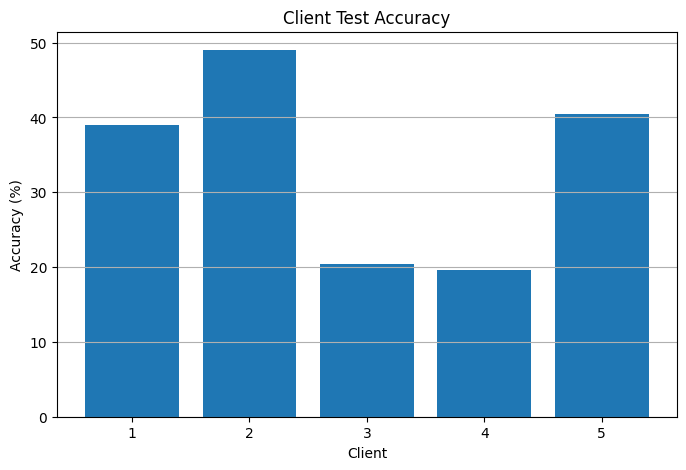

In [ ]:
# ============================================================
# Client Accuracy Plot
# ============================================================

plt.figure(figsize=(8,5))

plt.bar(
    range(1, len(client_accuracies) + 1),
    client_accuracies
)

plt.xlabel("Client")

plt.ylabel("Accuracy (%)")

plt.title("Client Test Accuracy")

plt.xticks(range(1, len(client_accuracies) + 1))

plt.grid(axis="y")

plt.show()

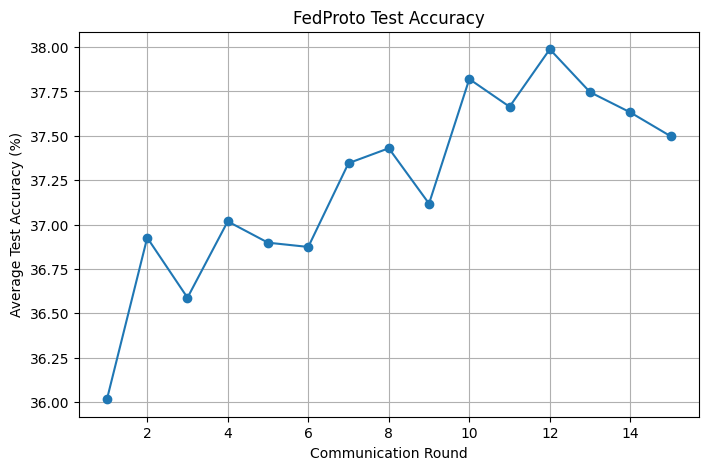

In [ ]:
# ============================================================
# Plot Accuracy
# ============================================================

plt.figure(figsize=(8,5))

plt.plot(
    range(1, NUM_ROUNDS + 1),
    round_accuracies,
    marker="o"
)

plt.xlabel("Communication Round")

plt.ylabel("Average Test Accuracy (%)")

plt.title("FedProto Test Accuracy")

plt.grid(True)

plt.show()

# Experiments under Different Statistical Heterogeneity

The performance of federated learning algorithms is highly influenced by the degree of statistical heterogeneity among participating clients. To evaluate the robustness of FedProto under different data distributions, we conduct experiments using multiple **Dirichlet concentration parameters (α)**.

For each value of α, the entire federated learning process is repeated from scratch. This includes:

- Creating a new Dirichlet partition of the training dataset.
- Constructing new client datasets and DataLoaders.
- Initializing fresh heterogeneous client models.
- Creating new client and server objects.
- Training FedProto for the specified number of communication rounds.
- Evaluating the average test accuracy after every communication round.

To ensure a fair comparison, all hyperparameters (number of clients, communication rounds, local epochs, optimizer, learning rate, and model architectures) remain unchanged across experiments. Only the Dirichlet concentration parameter is varied.

The following experiments are performed:

- **α = 1.0** : Mild statistical heterogeneity.
- **α = 0.5** : Moderate statistical heterogeneity.
- **α = 0.1** : Strong statistical heterogeneity.

For each experiment, we record:

- Average training loss after every communication round.
- Average test accuracy after every communication round.
- Final average test accuracy.

Finally, the learning curves obtained under different heterogeneity levels are compared to study how increasing statistical heterogeneity affects the convergence and performance of the FedProto algorithm.

In [ ]:
# ============================================================
# Run One Complete FedProto Experiment
# ============================================================

def run_fedproto_experiment(alpha):
    """
    Run one complete FedProto experiment for a given
    Dirichlet alpha.

    Parameters
    ----------
    alpha : float
        Dirichlet concentration parameter.

    Returns
    -------
    dict
        Dictionary containing:
            - loss_history
            - accuracy_history
            - final_accuracy
    """

    print("=" * 70)
    print(f"Starting Experiment (Dirichlet α = {alpha})")
    print("=" * 70)

    # --------------------------------------------------------
    # Step 1: Create a new Dirichlet partition
    # --------------------------------------------------------

    client_indices = dirichlet_partition(
        dataset=train_dataset,
        num_clients=NUM_CLIENTS,
        alpha=alpha,
        seed=SEED
    )

    # --------------------------------------------------------
    # Step 2: Create fresh client datasets
    # --------------------------------------------------------

    client_datasets = create_client_datasets(
        train_dataset,
        client_indices
    )

    client_loaders = create_client_dataloaders(
        client_datasets,
        batch_size=BATCH_SIZE
    )

    # --------------------------------------------------------
    # Step 3: Create fresh heterogeneous models
    # --------------------------------------------------------

    experiment_models = {
        client_id: create_model(model_name).to(DEVICE)
        for client_id, model_name in enumerate(client_model_names)
    }

    # --------------------------------------------------------
    # Step 4: Create fresh clients
    # --------------------------------------------------------

    experiment_clients = []

    for client_id in range(NUM_CLIENTS):

        experiment_clients.append(

            Client(
                client_id=client_id,
                model=experiment_models[client_id],
                train_loader=client_loaders[client_id]
            )

        )

    # --------------------------------------------------------
    # Step 5: Create a fresh server
    # --------------------------------------------------------

    experiment_server = Server()

    # --------------------------------------------------------
    # Step 6: Training
    # --------------------------------------------------------

    loss_history = []

    accuracy_history = []

    for round_idx in range(NUM_ROUNDS):

        stats = communication_round(
            experiment_server,
            experiment_clients
        )

        avg_accuracy = np.mean([

            evaluate_client(
                client,
                test_loader
            )

            for client in experiment_clients

        ])

        loss_history.append(
            stats["average_loss"]
        )

        accuracy_history.append(
            avg_accuracy
        )

        print(
            f"Round {round_idx + 1:02d}/{NUM_ROUNDS}"
            f" | Loss: {stats['average_loss']:.4f}"
            f" | Accuracy: {avg_accuracy:.2f}%"
        )

    print()

    print(
        f"Finished α = {alpha}"
    )

    print(
        f"Final Accuracy = {accuracy_history[-1]:.2f}%"
    )

    print()

    return {

        "alpha": alpha,

        "loss_history": loss_history,

        "accuracy_history": accuracy_history,

        "final_accuracy": accuracy_history[-1]

    }

In [ ]:
# ============================================================
# Run FedProto under Multiple Heterogeneity Levels
# ============================================================

# Dirichlet alpha values to compare
experiment_alphas = [1.0, 0.5, 0.1]

# Store results for every experiment
experiment_results = {}

# ============================================================
# Execute Experiments
# ============================================================

for alpha in experiment_alphas:

    result = run_fedproto_experiment(alpha)

    experiment_results[alpha] = result

print("=" * 70)
print("All Experiments Completed Successfully")
print("=" * 70)

# ============================================================
# Display Final Accuracy Summary
# ============================================================

print("\nFinal Test Accuracies\n")

for alpha in experiment_alphas:

    accuracy = experiment_results[alpha]["final_accuracy"]

    print(
        f"Dirichlet α = {alpha:<4} "
        f"-> Final Accuracy = {accuracy:.2f}%"
    )

Starting Experiment (Dirichlet α = 1.0)
Round 01/15 | Loss: 0.5515 | Accuracy: 85.58%
Round 02/15 | Loss: 2.1151 | Accuracy: 87.12%
Round 03/15 | Loss: 0.8208 | Accuracy: 91.08%
Round 04/15 | Loss: 0.5001 | Accuracy: 91.91%
Round 05/15 | Loss: 0.3448 | Accuracy: 94.20%
Round 06/15 | Loss: 0.2549 | Accuracy: 94.84%
Round 07/15 | Loss: 0.1976 | Accuracy: 95.27%
Round 08/15 | Loss: 0.1594 | Accuracy: 95.65%
Round 09/15 | Loss: 0.1357 | Accuracy: 94.80%
Round 10/15 | Loss: 0.1163 | Accuracy: 96.23%
Round 11/15 | Loss: 0.0943 | Accuracy: 96.02%
Round 12/15 | Loss: 0.0807 | Accuracy: 96.08%
Round 13/15 | Loss: 0.0758 | Accuracy: 96.31%
Round 14/15 | Loss: 0.0670 | Accuracy: 96.23%
Round 15/15 | Loss: 0.0606 | Accuracy: 95.80%

Finished α = 1.0
Final Accuracy = 95.80%

Starting Experiment (Dirichlet α = 0.5)
Round 01/15 | Loss: 0.4840 | Accuracy: 65.37%
Round 02/15 | Loss: 1.4778 | Accuracy: 66.29%
Round 03/15 | Loss: 0.6118 | Accuracy: 74.08%
Round 04/15 | Loss: 0.3971 | Accuracy: 76.03%
Rou

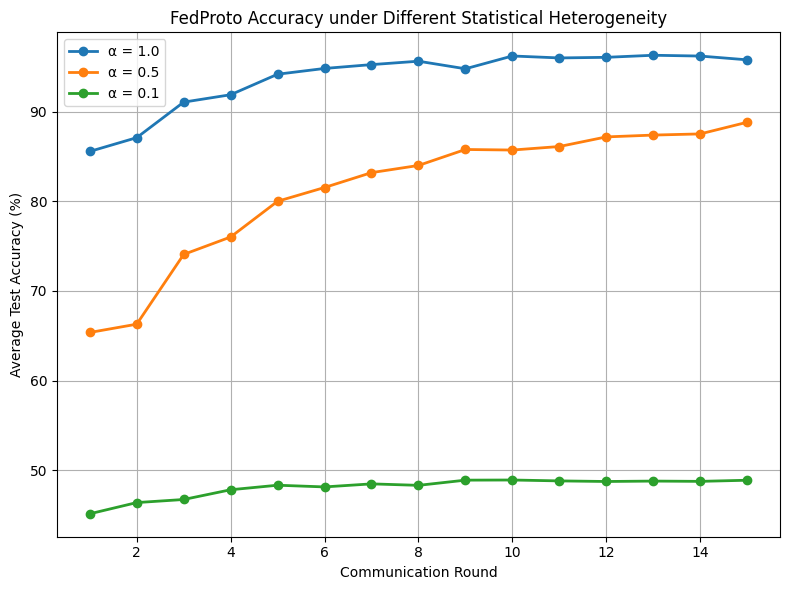

In [ ]:
plt.figure(figsize=(8,6))

for alpha in experiment_alphas:

    plt.plot(
        range(1, NUM_ROUNDS + 1),
        experiment_results[alpha]["accuracy_history"],
        marker="o",
        linewidth=2,
        label=f"α = {alpha}"
    )

plt.xlabel("Communication Round")
plt.ylabel("Average Test Accuracy (%)")
plt.title("FedProto Accuracy under Different Statistical Heterogeneity")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

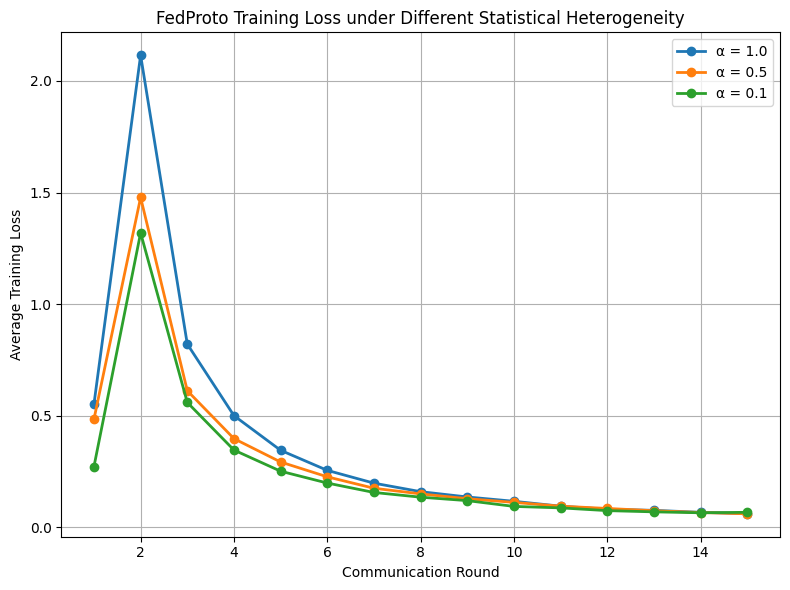

In [ ]:
plt.figure(figsize=(8,6))

for alpha in experiment_alphas:

    plt.plot(
        range(1, NUM_ROUNDS + 1),
        experiment_results[alpha]["loss_history"],
        marker="o",
        linewidth=2,
        label=f"α = {alpha}"
    )

plt.xlabel("Communication Round")
plt.ylabel("Average Training Loss")
plt.title("FedProto Training Loss under Different Statistical Heterogeneity")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# Summary of Experimental Results
# ============================================================

import pandas as pd

summary = pd.DataFrame({

    "Dirichlet Alpha": experiment_alphas,

    "Final Training Loss": [
        experiment_results[a]["loss_history"][-1]
        for a in experiment_alphas
    ],

    "Final Test Accuracy (%)": [
        experiment_results[a]["final_accuracy"]
        for a in experiment_alphas
    ]

})

summary = summary.sort_values(
    by="Dirichlet Alpha",
    ascending=False
)

summary = summary.reset_index(drop=True)

print("\nSummary of FedProto Performance\n")

display(summary)


Summary of FedProto Performance



,Dirichlet Alpha,Final Training Loss,Final Test Accuracy (%)
0,1.0,0.060647,95.804
1,0.5,0.060307,88.834
2,0.1,0.066943,48.874
